# Unsupervised Learning and Recommendations with Scikit Learn

This tutorial is a part of the [Machine Learning with Python: Zero to GBMs](http://zerotogbms.com) and [Zero to Data Science Bootcamp by Jovian](https://zerotodatascience.com).

![](https://i.imgur.com/eyfi64y.png)

The following topics are covered in this tutorial:

- Overview of unsupervised learning algorithms in Scikit-learn
- Clustering algorithms: K Means, DBScan, Hierarchical clustering etc.
- Dimensionality reduction (PCA) and manifold learning (t-SNE)

Let's install the required libraries.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px
import numpy as np

## Introduction to Unsupervised Learning

Unsupervised machine learning refers to the category of machine learning techniques where models are trained on a dataset without labels. Unsupervised learning is generally use to discover patterns in data and reduce high-dimensional data to fewer dimensions. Here's how unsupervised learning fits into the landscape of machine learning algorithms([source](https://medium.datadriveninvestor.com/machine-learning-in-10-minutes-354d83e5922e)):

<img src="https://miro.medium.com/max/842/1*tlQwBmbL6RkuuFq8OPJofw.png" width="640">

Here are the topics in machine learning that we're studying in this course ([source](https://vas3k.com/blog/machine_learning/)): 

<img src="https://i.imgur.com/VbVFAsg.png" width="640">

Lots of data that we work with today is tabular i.e excell sheets, CSV files etc and for tabular data tehe best known ML algorithms are Classical ML algorithms only that we have already explored in previous lectures.

Today we are exploring the unsupervised learning where there is no label for any data and we either try and cluster the data or we try to reduce the dimensins of the data or we try and find association within the data and use that as models such as recomendations.

## Clustering 

Clustering is the process of grouping objects from a dataset such that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups ([Wikipedia](https://en.wikipedia.org/wiki/Cluster_analysis)). Scikit-learn offers several clustering algorithms. You can learn more about them here: https://scikit-learn.org/stable/modules/clustering.html

Here is a visual representation of clustering:

<img src="https://i.imgur.com/VXPgw6H.png" width="400">


Here are some real-world applications of clustering:

* Customer segmentation 
* Product recommendation
* Feature engineering
* Anomaly/fraud detection
* Taxonomy creation

We'll use the [Iris flower dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) to study some of the clustering algorithms available in `scikit-learn`. It contains various measurements for 150 flowers belonging to 3 different species.

In [18]:
sb.set_style('darkgrid')
iris_df = sb.load_dataset('iris')
iris_df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


For learning clustering, we will suppose the species column doesnt exist and treat the data as unlabled.

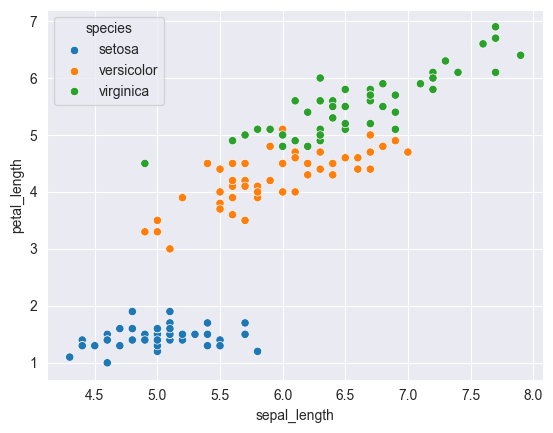

In [19]:
sb.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species');

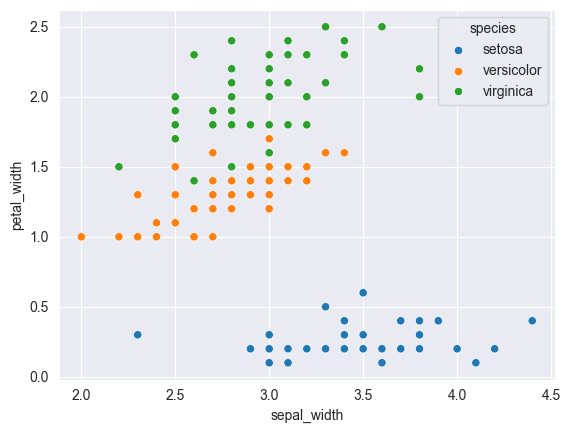

In [20]:
sb.scatterplot(data=iris_df, x='sepal_width', y='petal_width', hue='species');

### 3D visualisatiopn using plotly

we can also visualise the dataset in 3d using the plotly library and see the diagram formed using 3 dimensions for a better clarity and understanding of data in a 3d plane.

If we didnt have the species columns, our visualizaton would look like.

In [21]:
fig = px.scatter_3d(
    iris_df,
    x='sepal_length', 
    y='sepal_width', 
    z='petal_length',
    color='species'
)
fig.show()

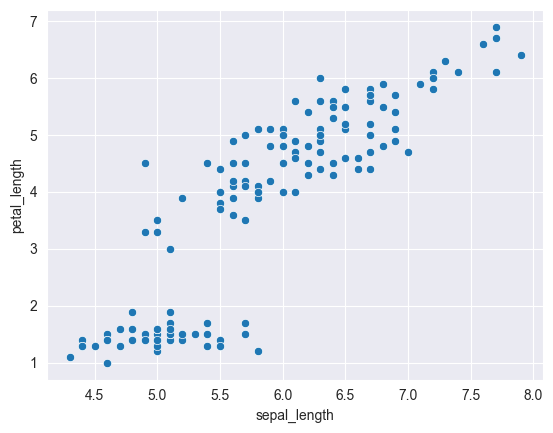

In [22]:
sb.scatterplot(data=iris_df, x='sepal_length', y='petal_length');

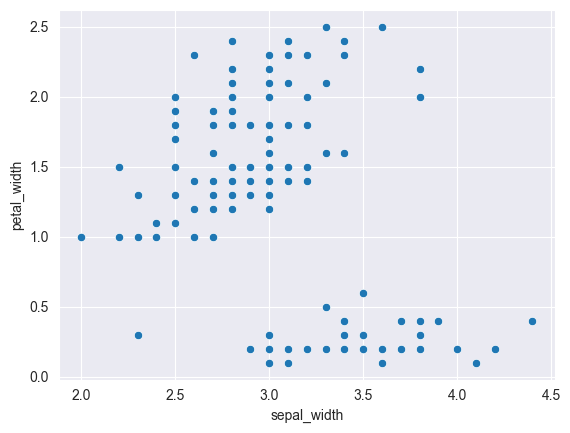

In [23]:
sb.scatterplot(data=iris_df, x='sepal_width', y='petal_width');

In [24]:
fig = px.scatter_3d(
    iris_df,
    x='sepal_length', 
    y='sepal_width', 
    z='petal_length'
)
fig.show()

We'll attempt to cluster observations using numeric columns in the data. 

In [25]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

In [26]:
X = iris_df[numeric_cols]

### Hierarchical Clustering

Hierarchical clustering, as the name suggests, creates a hierarchy or a tree of clusters.

<img src="https://dashee87.github.io/images/hierarch.gif" width="640">

While there are several approaches to hierarchical clustering, the most common approach works as follows:

1. Mark each point in the dataset as a cluster.
2. Pick the two closest cluster centers without a parent and combine them into a new cluster. 
3. The new cluster is the parent cluster of the two clusters, and its center is the mean of all the points in the cluster.
3. Repeat steps 2 and 3 till there's just one cluster left.

Watch this video for a visual explanation of hierarchical clustering: https://www.youtube.com/watch?v=7xHsRkOdVwo

> **EXERCISE**: Implement hierarchical clustering for the Iris dataset using `scikit-learn`.

In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Create model
hc = AgglomerativeClustering(
    n_clusters=3,        # Number of clusters you want
    metric='euclidean', # Distance metric: euclidean/manhattan/cosine
    linkage='ward'        # Linkage: ward, complete, average, single
)

# Fit and predict cluster labels
labels = hc.fit_predict(X_scaled)

# Add cluster labels to your dataset if needed
df = pd.DataFrame(X, columns=iris_df.feature_names)
df['Cluster'] = labels


AttributeError: 'DataFrame' object has no attribute 'feature_names'

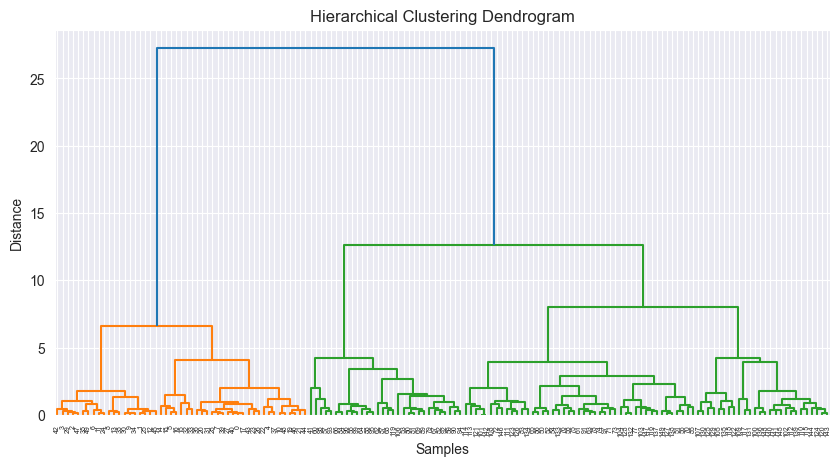

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Perform linkage (same parameters as above)
Z = linkage(X_scaled, method='ward')  # ward linkage

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()
